# 01: Pair Selection Analysis

This notebook documents the research for the pairs trading system, focusing on the identification and validation of mean-reverting equity pairs.

## 1. Universe Overview

The strategy operates on a universe of **S&P 500 equities** categorized by their Global Industry Classification Standard (GICS) sectors. 

### Universe Selection Rationale
High-volume stocks ensure execution symmetry and minimal slippage for capturing mean-reversion spreads.
Trading pairs within the same sector isolates relative-value opportunities while neutralizing sector-wide trends.
Equities exhibit similar borrow availability and transaction costs, preventing liquidity constraints in the spread.

In [10]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# Add src to path
sys.path.append('../')
from src.data_loader import DataLoader
from src.pair_selection import PairSelector
from src.signal import compute_residuals, estimate_ar1
from src.constants import SECTOR_MAP

# Display Sector Universe
universe_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in SECTOR_MAP.items() ]))
universe_df.fillna('')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Tech,Financials,CommServices,Staples,Discretionary,Healthcare,Energy,Industrials
0,AAPL,JPM,GOOGL,PG,AMZN,JNJ,XOM,GE
1,MSFT,V,META,KO,TSLA,UNH,CVX,HON
2,CRM,MA,NFLX,PEP,HD,LLY,COP,UPS
3,ADBE,BAC,VZ,WMT,MCD,ABT,SLB,UNP
4,TXN,GS,DIS,COST,NKE,DHR,EOG,CAT
5,NVDA,MS,CMCSA,MDLZ,LOW,TMO,MPC,BA
6,INTC,AXP,TMUS,CL,SBUX,PFE,PSX,LMT
7,CSCO,PYPL,T,MO,TJX,MRK,,RTX
8,ORCL,,,,,AMGN,,
9,AVGO,,,,,GILD,,


## 2. Cointegration Comparison: Stationary vs. Non-Stationary

The core of the identification process is the **Engle-Granger Two-Step Cointegration Test**. We define a pair as mean-reverting if a linear combination of their prices (the residual) is stationary.

Below we compare a non-cointegrated pair (**KO** vs **PEP**) where the spread drifts, against a cointegrated pair (**CMCSA** vs **DIS**) which exhibits clear mean reversion.

c:\Users\hansg\OneDrive\Desktop\CodingMaster\FoldOptimization\GITHUBREPO\notebooks\..\src\data_loader.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return df.dropna(how='all')
c:\Users\hansg\OneDrive\Desktop\CodingMaster\FoldOptimization\GITHUBREPO\notebooks\..\src\data_loader.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return df.dropna(how='all')


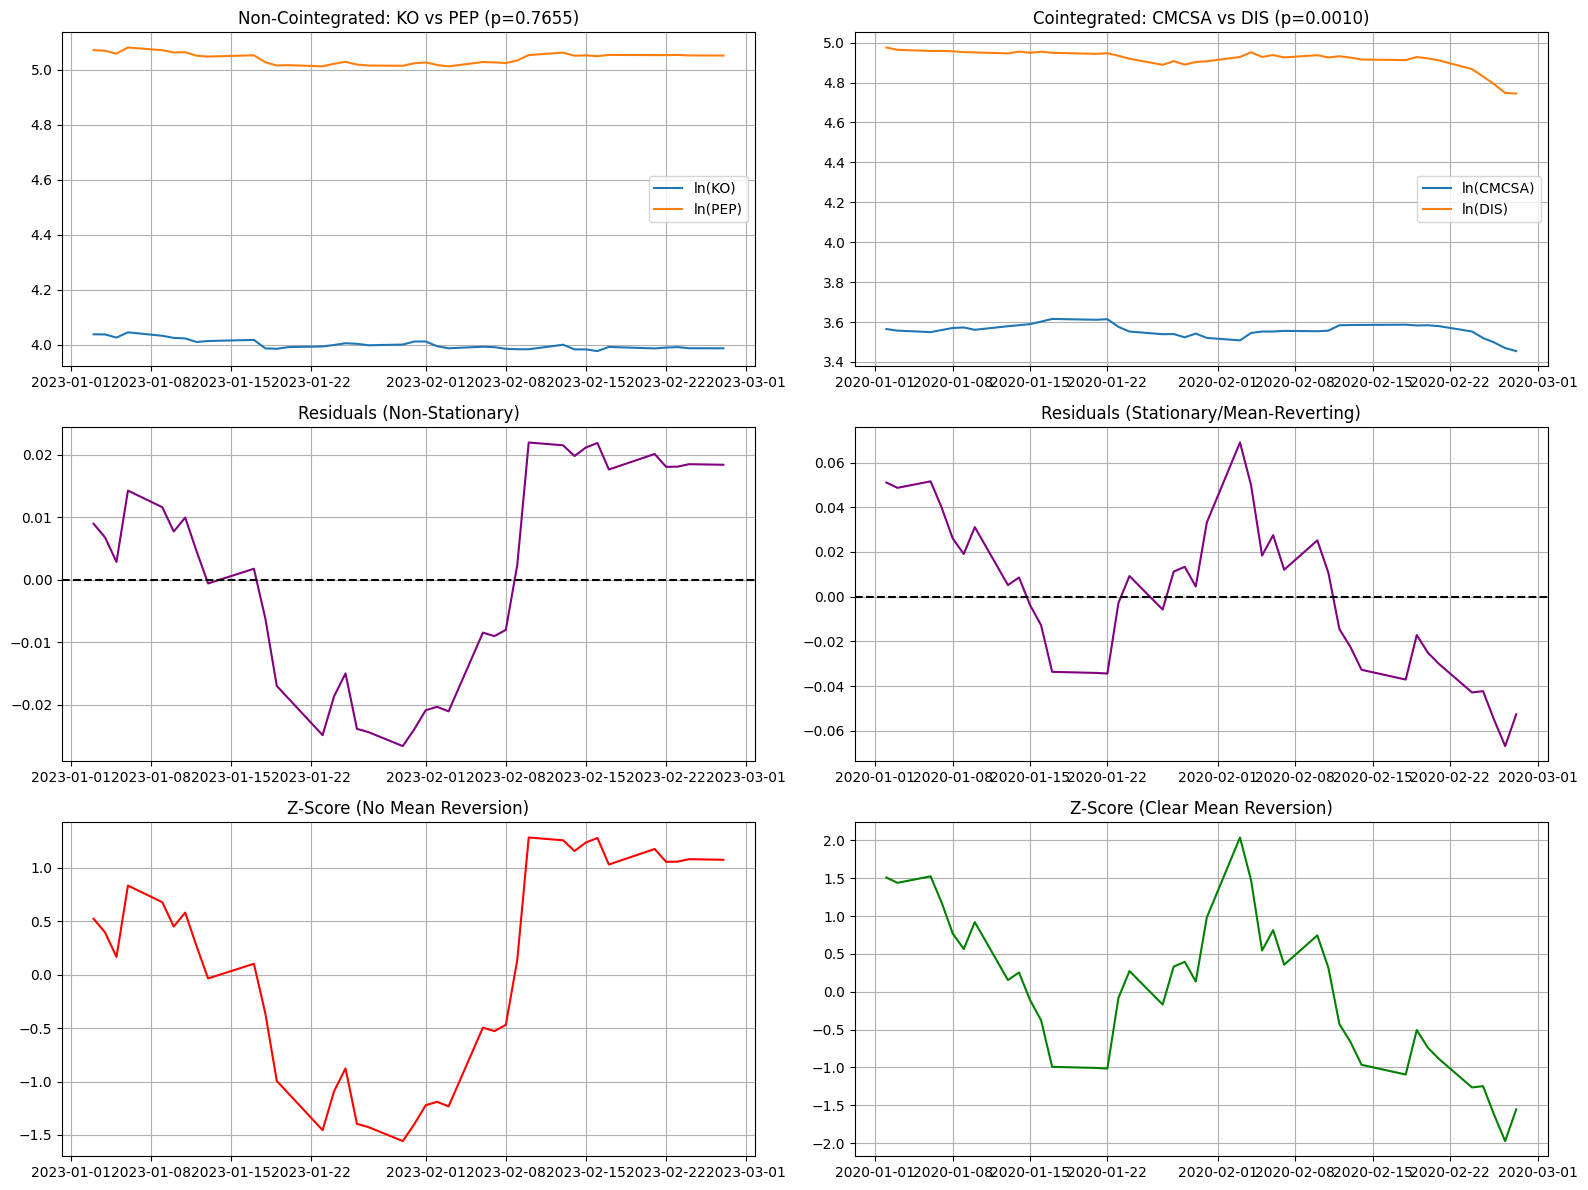

In [13]:
# 1. Load Data for Both Examples
# Non-Cointegrated: KO vs PEP (2023)
start_a, end_a = "2023-01-01", "2023-02-28"
loader_a = DataLoader(['KO', 'PEP'], start=start_a, end=end_a, use_warmup=False)
prices_a = loader_a.fetch_prices()['Close']
s1_a, s2_a = np.log(prices_a['KO']), np.log(prices_a['PEP'])
res_a = compute_residuals(prices_a['KO'], prices_a['PEP'], log_space=True)['residual']
p_a = coint(s1_a, s2_a)[1]

# Cointegrated: CMCSA vs DIS (Early 2020)
start_b, end_b = "2020-01-01", "2020-02-29"
loader_b = DataLoader(['CMCSA', 'DIS'], start=start_b, end=end_b, use_warmup=False)
prices_b = loader_b.fetch_prices()['Close']
s1_b, s2_b = np.log(prices_b['CMCSA']), np.log(prices_b['DIS'])
res_b = compute_residuals(prices_b['CMCSA'], prices_b['DIS'], log_space=True)['residual']
p_b = coint(s1_b, s2_b)[1]

# 2. Visualization Comparison
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# --- Column 0: Non-Cointegrated ---
axes[0, 0].plot(s1_a, label='ln(KO)')
axes[0, 0].plot(s2_a, label='ln(PEP)')
axes[0, 0].set_title(f"Non-Cointegrated: KO vs PEP (p={p_a:.4f})")
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[1, 0].plot(res_a, color='purple')
axes[1, 0].axhline(0, color='black', linestyle='--')
axes[1, 0].set_title("Residuals (Non-Stationary)")
axes[1, 0].grid(True)

z_a = (res_a - res_a.mean()) / res_a.std()
axes[2, 0].plot(z_a, color='red')
axes[2, 0].set_title("Z-Score (No Mean Reversion)")
axes[2, 0].grid(True)

# --- Column 1: Cointegrated ---
axes[0, 1].plot(s1_b, label='ln(CMCSA)')
axes[0, 1].plot(s2_b, label='ln(DIS)')
axes[0, 1].set_title(f"Cointegrated: CMCSA vs DIS (p={p_b:.4f})")
axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 1].plot(res_b, color='purple')
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_title("Residuals (Stationary/Mean-Reverting)")
axes[1, 1].grid(True)

z_b = (res_b - res_b.mean()) / res_b.std()
axes[2, 1].plot(z_b, color='green')
axes[2, 1].set_title("Z-Score (Clear Mean Reversion)")
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

## 3. Pair Survival Rate Analysis

Statistical decay is a documented characteristic: cointegration often breaks before trading begins. To find a robust walk-forward structure, we conducted a study across various Selection and Test window lengths.

**Survival Rate** is defined as the percentage of pairs that passed cointegration testing in the selection window AND remained cointegrated ($p < 0.05$) during the out-of-sample test window.

<img src="../results/pair_selection/survival_heatmap.png" width="1000">

### Selection and Test Window Rationale
Research showed that a **2-month selection window** captures current cointegration relationships. Longer windows (12m) select pairs that have already begun to decay.
Performance decays significantly beyond 3 months in the 3-month window, aligning with the observed 20-40 day half-lives of the universe.

## 4. Top-N Sensitivity Analysis

Pair selection involves a trade-off between **Alpha Concentration** (trading only the most cointegrated pair) and **Robustness** (trading a portfolio).

<img src="../results/pair_selection/top_n_sensitivity.png" width="1000">

Sensitivity analysis shows that while Top-1 pairs offer higher returns, they exhibit variance. A **Top-5 selection** provides risk-adjusted stability, ensuring that a single regime break doesn't lead to excessive variance.

## 5. Concrete Fold Example

Finally, let's look at the output of the `PairSelector` for a specific fold in early 2024.

In [14]:
# Run PairSelector on a recent fold
from src.constants import TICKERS, SECTOR_MAP

fold_start, fold_end = "2020-01-01", "2020-02-29"
loader_final = DataLoader(TICKERS, start=fold_start, end=fold_end, use_warmup=False)
master_df = loader_final.fetch_prices()

selector_final = PairSelector(pvalue_threshold=0.05)
fold_pairs = selector_final.select_pairs(master_df, SECTOR_MAP, fold_start, fold_end)

print(f"Top Selected Pairs for Fold {fold_start} to {fold_end}:")
fold_pairs[['pair', 'sector', 'cointegration_pvalue', 'cointegration_pvalue_log', 'half_life']].head(10)

c:\Users\hansg\OneDrive\Desktop\CodingMaster\FoldOptimization\GITHUBREPO\notebooks\..\src\data_loader.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return df.dropna(how='all')


Top Selected Pairs for Fold 2020-01-01 to 2020-02-29:


,pair,sector,cointegration_pvalue,cointegration_pvalue_log,half_life
0,CMCSA-DIS,CommServices,0.000992,0.000962,6.207566
2,CL-MDLZ,Staples,0.001000,0.001028,0.965849
44,ORCL-TXN,Tech,0.002808,0.002270,1.021137
27,GILD-PFE,Healthcare,0.006743,0.012911,1.566262
44,TMO-UNH,Healthcare,0.015277,0.017174,1.125824
12,EOG-PSX,Energy,0.009931,0.021662,1.717194
3,CMCSA-NFLX,CommServices,0.021142,0.023637,6.241279
26,GILD-MRK,Healthcare,0.038070,0.043789,1.833070
19,PSX-XOM,Energy,0.017109,0.046014,1.903750
